![Brats official annotations](https://www.med.upenn.edu/cbica/assets/user-content/images/BraTS/brats-tumor-subregions.jpg)

# Setup env

In [ ]:
!pip install segmentation-models albumentations monai keras-tuner optuna

In [9]:
import os
import cv2
import glob
import PIL
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import montage
import skimage.transform as skTrans
from skimage.transform import rotate
from skimage.transform import resize
from PIL import Image, ImageOps


# neural imaging
import nilearn as nl
import nibabel as nib
import nilearn.plotting as nlplt
try:
    import gif_your_nifti.core as gif2nif
except Exception as e:
    gif2nif = None
    print(f"gif_your_nifti not available: {e}")


# ml libs
import keras
from tensorflow.keras import backend as K
from keras.callbacks import CSVLogger
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, TensorBoard

import segmentation_models as sm
import albumentations as A
import keras_tuner as kt
import optuna
import monai
from monai.networks.nets import UNet as MonaiUNet

# Make numpy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

gif_your_nifti not available: No module named 'gif_your_nifti'


In [10]:
# DEFINE seg-areas
SEGMENT_CLASSES = {
    0 : 'NOT tumor',
    1 : 'NECROTIC/CORE', # or NON-ENHANCING tumor CORE
    2 : 'EDEMA',
    3 : 'ENHANCING' # original 4 -> converted into 3 later
}

# there are 155 slices per volume
# to start at 22 and use 60 slices — reduced from 100 (40% less I/O per step = much faster)
VOLUME_SLICES = 60
VOLUME_START_AT = 22 # first slice of volume that we will include

# Image data descriptions

All BraTS multimodal scans are available as  NIfTI files (.nii.gz) -> commonly used medical imaging format to store brain imagin data obtained using MRI and describe different MRI settings
1. **T1**: T1-weighted, native image, sagittal or axial 2D acquisitions, with 1–6 mm slice thickness.
2. **T1c**: T1-weighted, contrast-enhanced (Gadolinium) image, with 3D acquisition and 1 mm isotropic voxel size for most patients.
3. **T2**: T2-weighted image, axial 2D acquisition, with 2–6 mm slice thickness.
4. **FLAIR**: T2-weighted FLAIR image, axial, coronal, or sagittal 2D acquisitions, 2–6 mm slice thickness.

Data were acquired with different clinical protocols and various scanners from multiple (n=19) institutions.

All the imaging datasets have been segmented manually, by one to four raters, following the same annotation protocol, and their annotations were approved by experienced neuro-radiologists. Annotations comprise the GD-enhancing tumor (ET — label 4), the peritumoral edema (ED — label 2), and the necrotic and non-enhancing tumor core (NCR/NET — label 1), as described both in the BraTS 2012-2013 TMI paper and in the latest BraTS summarizing paper. The provided data are distributed after their pre-processing, i.e., co-registered to the same anatomical template, interpolated to the same resolution (1 mm^3) and skull-stripped.



In [38]:
from pathlib import Path

def resolve_brats_paths():
    TRAIN_DATASET_PATH = "/content/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"
    VALIDATION_DATASET_PATH = "/content/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/"

print("TRAIN_DATASET_PATH =", TRAIN_DATASET_PATH)
print("VALIDATION_DATASET_PATH =", VALIDATION_DATASET_PATH)



TRAIN_DATASET_PATH = ../content/deep-learning project/BraTS-Data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/
VALIDATION_DATASET_PATH = /content/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/


In [40]:
import os

# List contents of the current directory
print('Listing contents of current directory:')
print(os.listdir('.'))

# List contents of /content (common for Colab uploads/mounts)
print('\nListing contents of /content:')
print(os.listdir('/content'))

# If you've mounted Google Drive, you might want to check /content/drive
# Uncomment the following lines if you have mounted Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# print('\nListing contents of /content/drive:')
# print(os.listdir('/content/drive'))


Listing contents of current directory:
['.config', 'training.log', 'model.png', 'BraTS2020_TrainingData', 'brats20-dataset-training-validation.zip', 'BraTS2020_ValidationData', 'kaggle.json', 'test_gif_BraTS20_Training_001_flair.nii', 'sample_data']

Listing contents of /content:
['.config', 'training.log', 'model.png', 'BraTS2020_TrainingData', 'brats20-dataset-training-validation.zip', 'BraTS2020_ValidationData', 'kaggle.json', 'test_gif_BraTS20_Training_001_flair.nii', 'sample_data']


After running the above cell, please examine the output to find the correct path to your `BraTS2020_TrainingData` and `BraTS2020_ValidationData` directories. Once you have the correct paths, you can modify the `resolve_brats_paths` function below with the explicit paths if the automatic detection still fails. You can replace the default return values with your correct paths.

TRAIN_DATASET_PATH = /content/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/
VALIDATION_DATASET_PATH = /content/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/


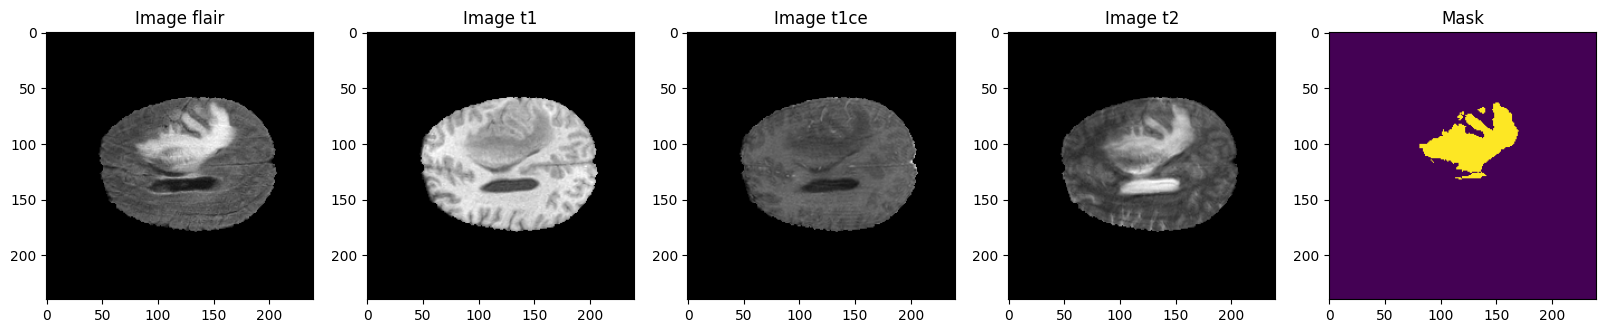

In [44]:
import nibabel as nib
import matplotlib.pyplot as plt

# Directly set the correct paths for Colab
TRAIN_DATASET_PATH = "/content/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"
VALIDATION_DATASET_PATH = "/content/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/"

print('TRAIN_DATASET_PATH =', TRAIN_DATASET_PATH)
print('VALIDATION_DATASET_PATH =', VALIDATION_DATASET_PATH)

# Load test images
test_image_flair = nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_flair.nii').get_fdata()
test_image_t1 = nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t1.nii').get_fdata()
test_image_t1ce = nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t1ce.nii').get_fdata()
test_image_t2 = nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t2.nii').get_fdata()
test_mask = nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_seg.nii').get_fdata()

# Plot
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20, 10))
slice_w = 25
ax1.imshow(test_image_flair[:, :, test_image_flair.shape[0] // 2 - slice_w], cmap='gray')
ax1.set_title('Image flair')
ax2.imshow(test_image_t1[:, :, test_image_t1.shape[0] // 2 - slice_w], cmap='gray')
ax2.set_title('Image t1')
ax3.imshow(test_image_t1ce[:, :, test_image_t1ce.shape[0] // 2 - slice_w], cmap='gray')
ax3.set_title('Image t1ce')
ax4.imshow(test_image_t2[:, :, test_image_t2.shape[0] // 2 - slice_w], cmap='gray')
ax4.set_title('Image t2')
ax5.imshow(test_mask[:, :, test_mask.shape[0] // 2 - slice_w])
ax5.set_title('Mask')
plt.show()

**Show whole nifti data -> print each slice from 3d data**

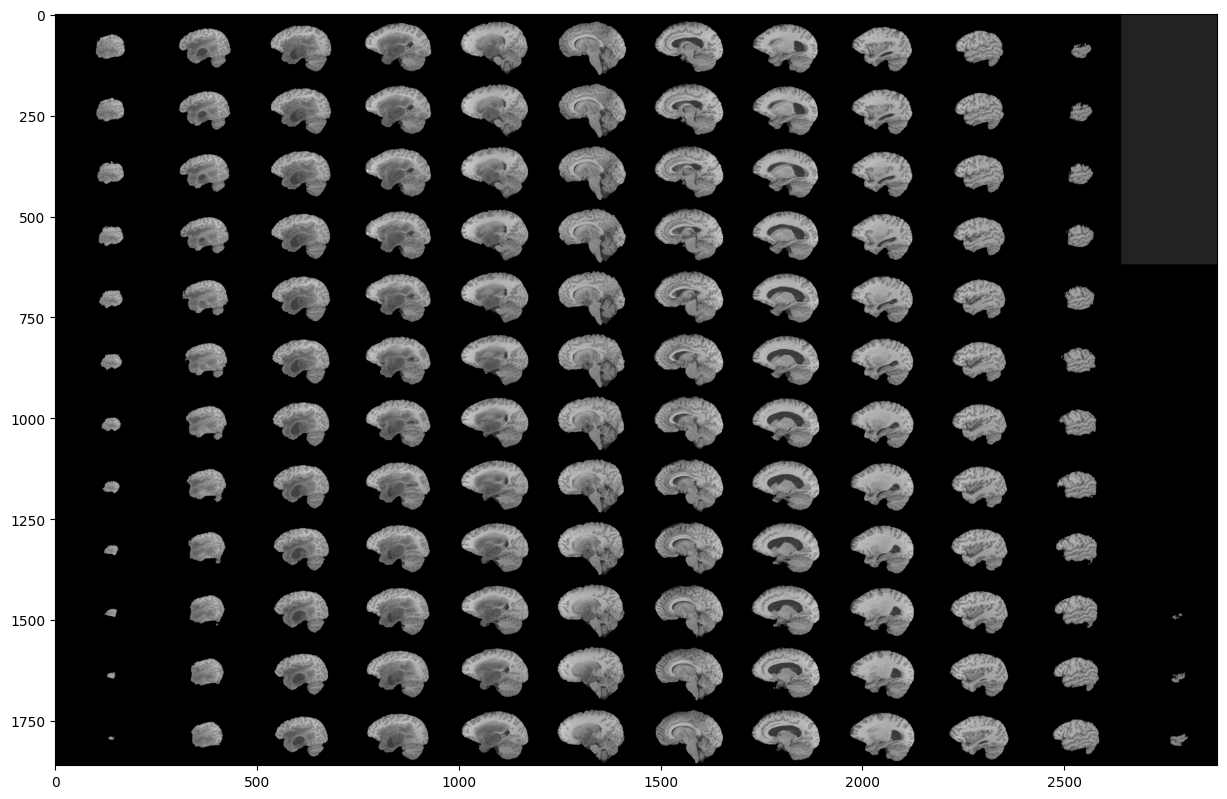

In [45]:
# Skip 50:-50 slices since there is not much to see
fig, ax1 = plt.subplots(1, 1, figsize = (15,15))
ax1.imshow(rotate(montage(test_image_t1[50:-50,:,:]), 90, resize=True), cmap ='gray')

**Show segment of tumor for each above slice**

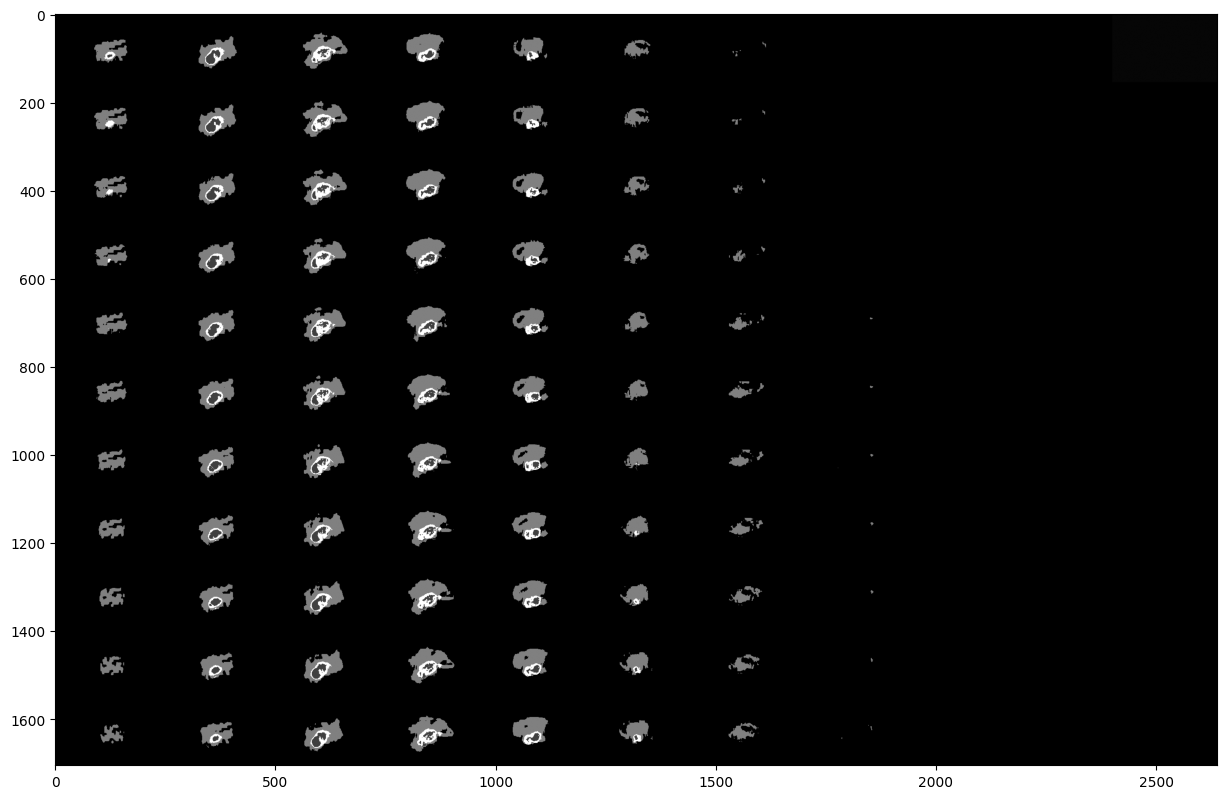

In [46]:
# Skip 50:-50 slices since there is not much to see
fig, ax1 = plt.subplots(1, 1, figsize = (15,15))
ax1.imshow(rotate(montage(test_mask[60:-60,:,:]), 90, resize=True), cmap ='gray')

In [47]:
import shutil

src_file = "/content/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_flair.nii"

# Destination path (where we want to copy it)
dst_file = "./test_gif_BraTS20_Training_001_flair.nii"

# Copy
shutil.copy2(src_file, dst_file)

'./test_gif_BraTS20_Training_001_flair.nii'

**Gif representation of slices in 3D volume**
<img src="https://media1.tenor.com/images/15427ffc1399afc3334f12fd27549a95/tenor.gif?itemid=20554734">

**Show segments of tumor using different effects**

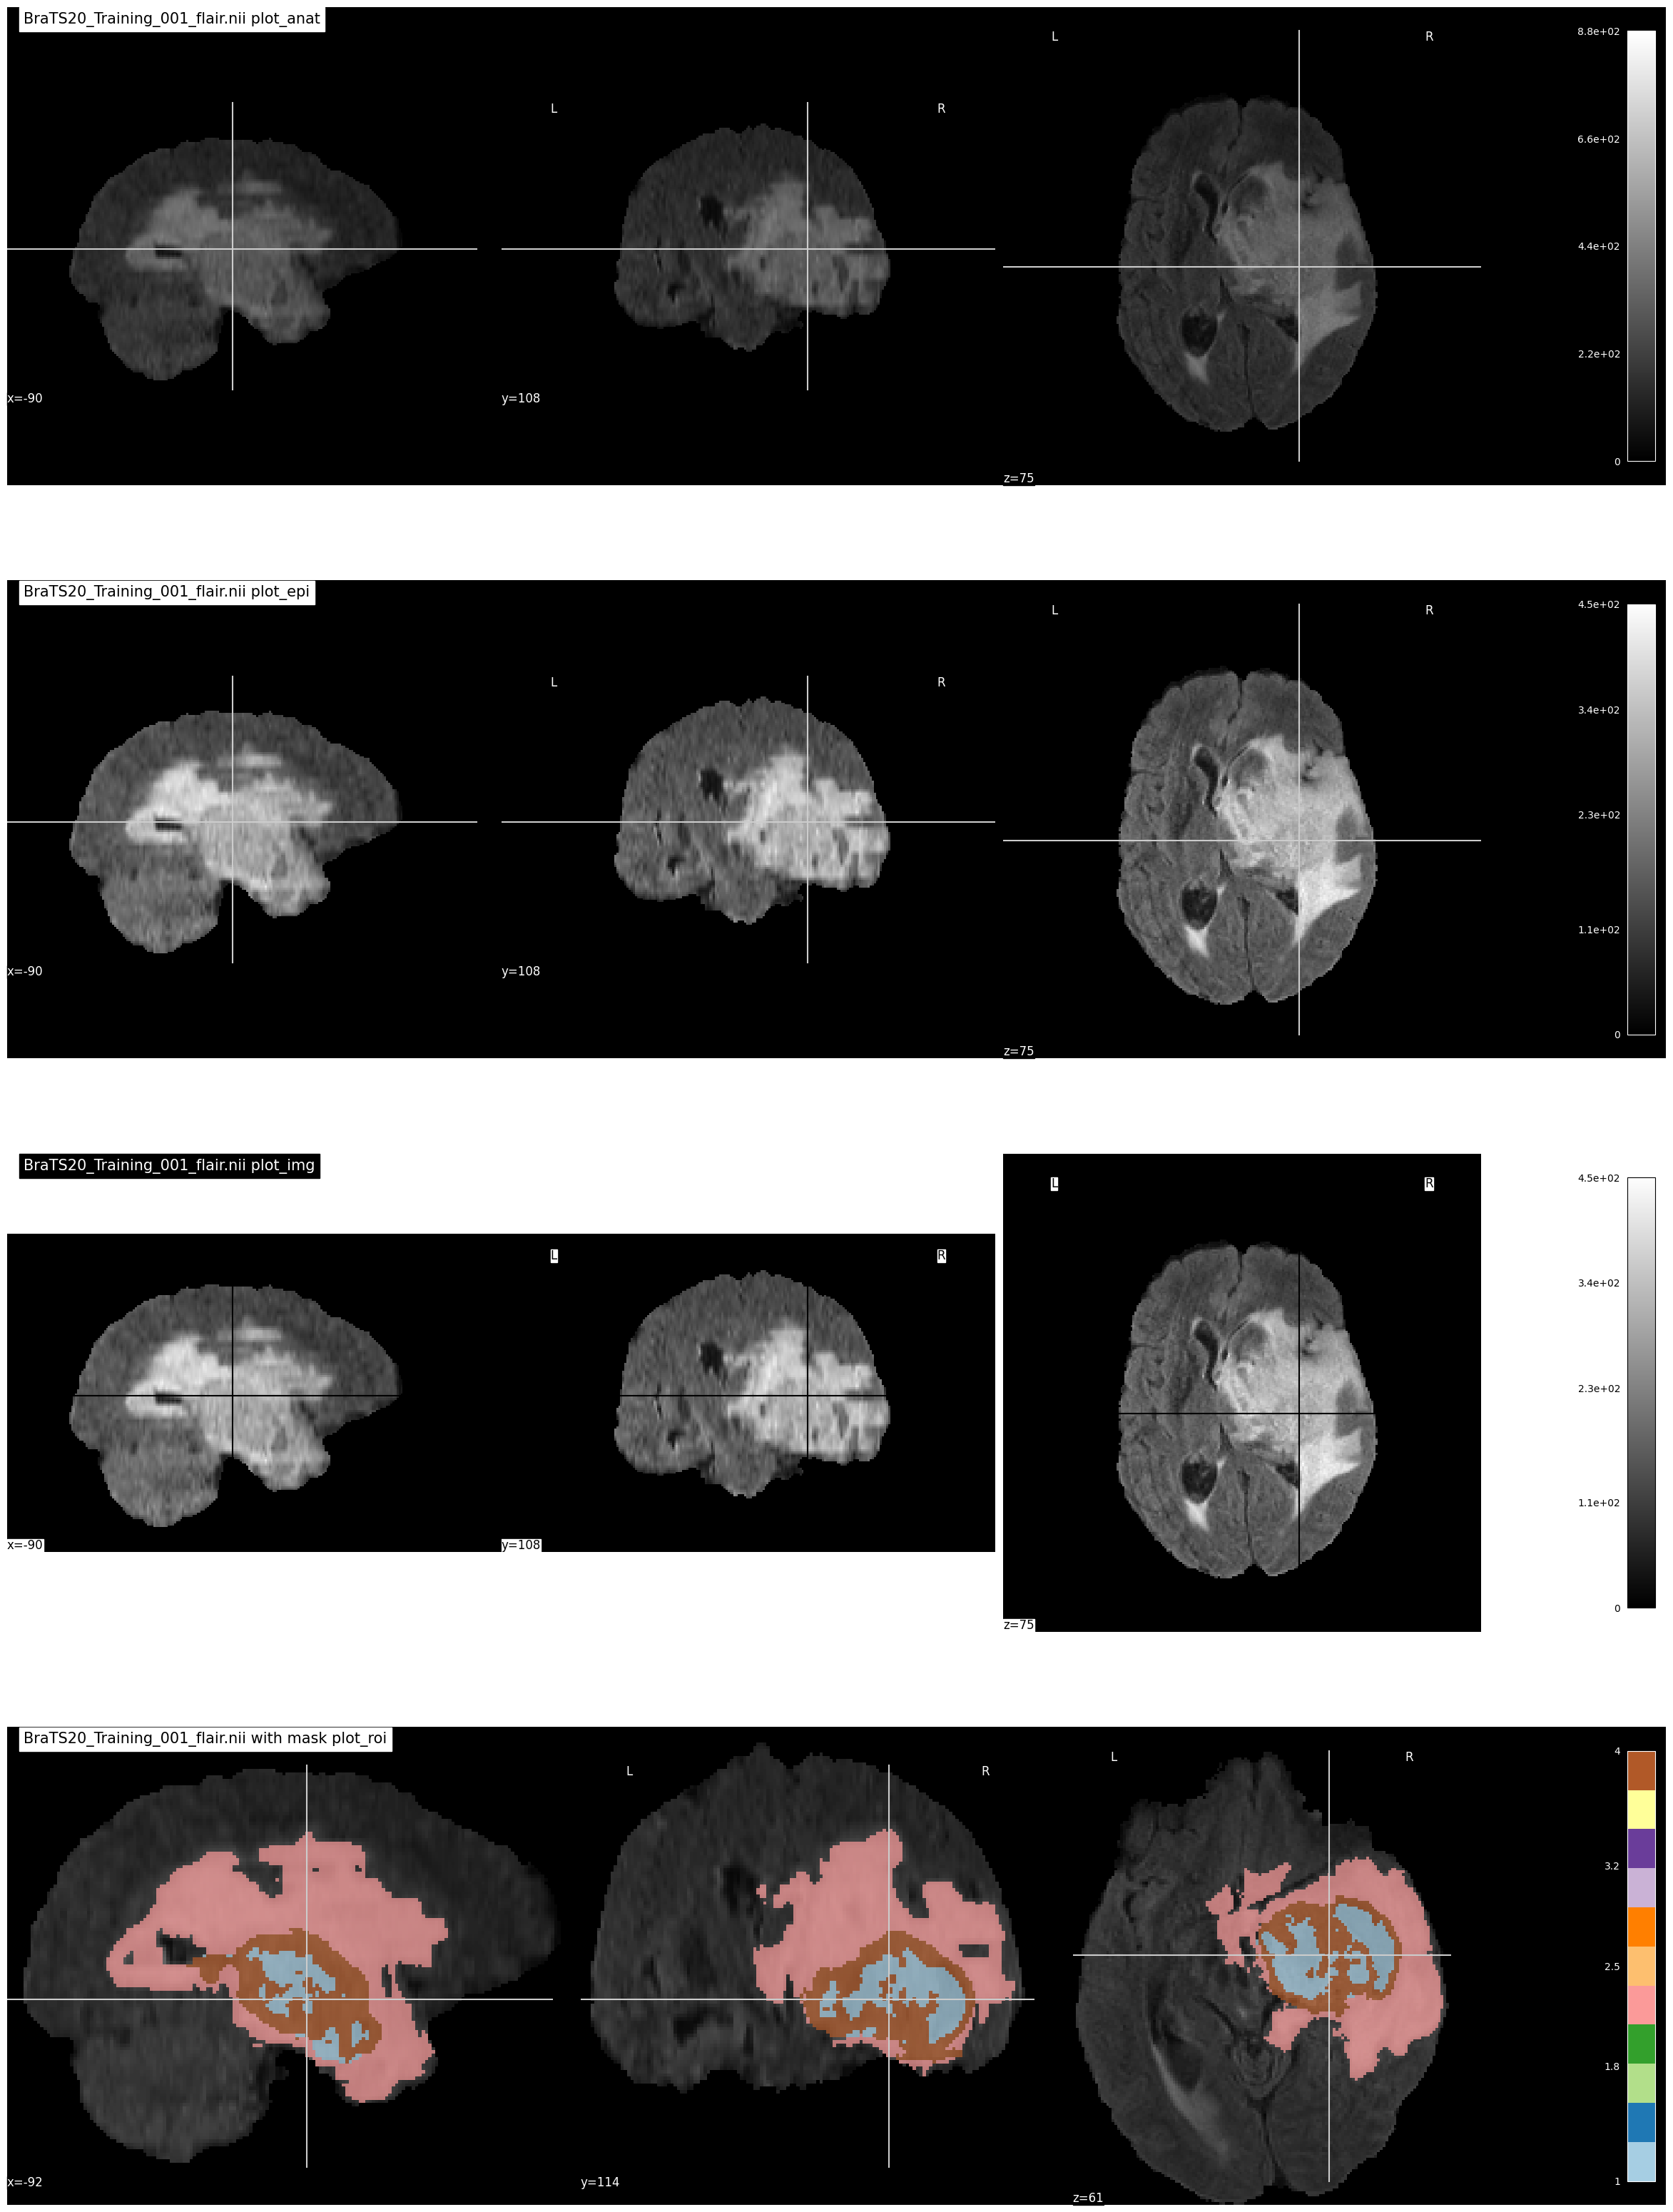

In [48]:
niimg = nl.image.load_img(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_flair.nii')
nimask = nl.image.load_img(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_seg.nii')

fig, axes = plt.subplots(nrows=4, figsize=(30, 40))


nlplt.plot_anat(niimg,
                title='BraTS20_Training_001_flair.nii plot_anat',
                axes=axes[0])

nlplt.plot_epi(niimg,
               title='BraTS20_Training_001_flair.nii plot_epi',
               axes=axes[1])

nlplt.plot_img(niimg,
               title='BraTS20_Training_001_flair.nii plot_img',
               axes=axes[2])

nlplt.plot_roi(nimask,
               title='BraTS20_Training_001_flair.nii with mask plot_roi',
               bg_img=niimg,
               axes=axes[3], cmap='Paired')

plt.show()

# Create model || U-Net: Convolutional Networks for Biomedical Image Segmentation
he u-net is convolutional network architecture for fast and precise segmentation of images. Up to now it has outperformed the prior best method (a sliding-window convolutional network) on the ISBI challenge for segmentation of neuronal structures in electron microscopic stacks. It has won the Grand Challenge for Computer-Automated Detection of Caries in Bitewing Radiography at ISBI 2015, and it has won the Cell Tracking Challenge at ISBI 2015 on the two most challenging transmitted light microscopy categories (Phase contrast and DIC microscopy) by a large margin
[more on](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/)
![official definiton](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)


# Loss function
**Dice coefficient**
, which is essentially a measure of overlap between two samples. This measure ranges from 0 to 1 where a Dice coefficient of 1 denotes perfect and complete overlap. The Dice coefficient was originally developed for binary data, and can be calculated as:

![dice loss](https://wikimedia.org/api/rest_v1/media/math/render/svg/a80a97215e1afc0b222e604af1b2099dc9363d3b)

**As matrices**
![dice loss](https://www.jeremyjordan.me/content/images/2018/05/intersection-1.png)

[Implementation, (images above) and explanation can be found here](https://www.jeremyjordan.me/semantic-segmentation/)

In [49]:
# dice loss as defined above for 4 classes
def dice_coef(y_true, y_pred, smooth=1e-6):
    # This works for both 2D (B, H, W, C) and 3D (B, D, H, W, C)
    # Flatten all but the last dimension
    # Using categorical dice: average of dice per class
    class_num = K.shape(y_true)[-1]
    
    # Flatten spatial dimensions: (Batch * Spatial) x Classes
    y_true_f = K.reshape(y_true, (-1, class_num))
    y_pred_f = K.reshape(y_pred, (-1, class_num))
    
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    union = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0)
    
    dice = (2. * intersection + smooth) / (union + smooth)
    return K.mean(dice)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def dice_ce_loss(y_true, y_pred):
    """Combined Dice and Categorical Cross-Entropy Loss"""
    return dice_loss(y_true, y_pred) + keras.losses.categorical_crossentropy(y_true, y_pred)


# define per class evaluation of dice coef
def dice_coef_necrotic(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[..., 1] * y_pred[..., 1]))
    return (2. * intersection) / (K.sum(K.square(y_true[..., 1])) + K.sum(K.square(y_pred[..., 1])) + epsilon)

def dice_coef_edema(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[..., 2] * y_pred[..., 2]))
    return (2. * intersection) / (K.sum(K.square(y_true[..., 2])) + K.sum(K.square(y_pred[..., 2])) + epsilon)

def dice_coef_enhancing(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[..., 3] * y_pred[..., 3]))
    return (2. * intersection) / (K.sum(K.square(y_true[..., 3])) + K.sum(K.square(y_pred[..., 3])) + epsilon)



# Computing Precision
def precision(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision


# Computing Sensitivity
def sensitivity(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    return true_positives / (possible_positives + K.epsilon())


# Computing Specificity
def specificity(y_true, y_pred):
    true_negatives = K.sum(K.round(K.clip((1-y_true) * (1-y_pred), 0, 1)))
    possible_negatives = K.sum(K.round(K.clip(1-y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())


In [50]:
IMG_SIZE=128

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

def train_svm_baseline(training_ids, n_samples=10000):
    X_features = []
    y_labels = []
    
    # Sample some pixels from training data
    sampled_ids = np.random.choice(training_ids, size=min(10, len(training_ids)), replace=False)
    
    for case_id in sampled_ids:
        case_path = os.path.join(TRAIN_DATASET_PATH, case_id)
        if not os.path.exists(case_path): continue
        flair = nib.load(os.path.join(case_path, f"{case_id}_flair.nii")).get_fdata()
        ce = nib.load(os.path.join(case_path, f"{case_id}_t1ce.nii")).get_fdata()
        seg = nib.load(os.path.join(case_path, f"{case_id}_seg.nii")).get_fdata()
        
        # Take a middle slice
        slice_idx = VOLUME_START_AT + VOLUME_SLICES // 2
        f_slice = cv2.resize(flair[:,:,slice_idx], (IMG_SIZE, IMG_SIZE))
        c_slice = cv2.resize(ce[:,:,slice_idx], (IMG_SIZE, IMG_SIZE))
        s_slice = cv2.resize(seg[:,:,slice_idx], (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        s_slice[s_slice == 4] = 3
        
        features = np.stack([f_slice.flatten(), c_slice.flatten()], axis=-1)
        labels = s_slice.flatten()
        
        X_features.append(features)
        y_labels.append(labels)
        
    if not X_features: return None, None
    X = np.concatenate(X_features, axis=0)
    y = np.concatenate(y_labels, axis=0)
    
    # Subsample to avoid memory issues and long training
    if X.shape[0] > n_samples:
        idx = np.random.choice(X.shape[0], n_samples, replace=False)
        X = X[idx]
        y = y[idx]
        
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    clf = LinearSVC(max_iter=1000)
    clf.fit(X_scaled, y)
    
    return clf, scaler

def predict_svm(clf, scaler, flair_img, ce_img):
    # input images should be (IMG_SIZE, IMG_SIZE)
    features = np.stack([flair_img.flatten(), ce_img.flatten()], axis=-1)
    features_scaled = scaler.transform(features)
    preds = clf.predict(features_scaled)
    return preds.reshape((IMG_SIZE, IMG_SIZE))


In [51]:
# Model Architectures: Baseline U-Net, Attention U-Net, 3D U-Net, and ResNet U-Net

def build_unet(inputs, ker_init="he_normal", dropout=0.2):
    conv1 = Conv2D(32, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(inputs)
    conv1 = Conv2D(32, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(pool1)
    conv2 = Conv2D(64, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(pool2)
    conv3 = Conv2D(128, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(pool3)
    conv4 = Conv2D(256, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(conv4)
    drop4 = Dropout(dropout)(conv4)

    up5 = concatenate([UpSampling2D(size=(2, 2))(drop4), conv3], axis=3)
    conv5 = Conv2D(128, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(up5)
    conv5 = Conv2D(128, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(conv5)

    up6 = concatenate([UpSampling2D(size=(2, 2))(conv5), conv2], axis=3)
    conv6 = Conv2D(64, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(up6)
    conv6 = Conv2D(64, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(conv6)

    up7 = concatenate([UpSampling2D(size=(2, 2))(conv6), conv1], axis=3)
    conv7 = Conv2D(32, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(up7)
    conv7 = Conv2D(32, 3, activation = "relu", padding = "same", kernel_initializer = ker_init)(conv7)

    outputs = Conv2D(4, (1, 1), activation = "softmax")(conv7)
    return Model(inputs=[inputs], outputs=[outputs], name="Baseline_UNet")

def build_resnet_unet(input_shape=(128, 128, 2), encoder_weights="imagenet"):
    import segmentation_models as sm
    sm.set_framework("tf.keras")
    model = sm.Unet(
        "resnet34",
        encoder_weights=encoder_weights,
        input_shape=input_shape,
        classes=4,
        activation="softmax"
    )
    return model

def attention_block(x, gating, inter_shape):
    phi_g = Conv2D(inter_shape, (1, 1), padding="same")(gating)
    theta_x = Conv2D(inter_shape, (3, 3), strides=(2, 2), padding="same")(x)
    concat_xg = add([phi_g, theta_x])
    act_xg = Activation("relu")(concat_xg)
    psi = Conv2D(1, (1, 1), padding="same")(act_xg)
    sigmoid_xg = Activation("sigmoid")(psi)
    upsample_psi = UpSampling2D(size=(K.int_shape(x)[1] // K.int_shape(sigmoid_xg)[1], 
                                     K.int_shape(x)[2] // K.int_shape(sigmoid_xg)[2]))(sigmoid_xg)
    y = multiply([upsample_psi, x])
    result = Conv2D(K.int_shape(x)[3], (1, 1), padding="same")(y)
    result_bn = BatchNormalization()(result)
    return result_bn

def build_attention_unet(input_shape=(128, 128, 2)):
    inputs = Input(input_shape)
    conv1 = Conv2D(32, 3, activation="relu", padding="same")(inputs)
    conv1 = Conv2D(32, 3, activation="relu", padding="same")(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = Conv2D(64, 3, activation="relu", padding="same")(pool1)
    conv2 = Conv2D(64, 3, activation="relu", padding="same")(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = Conv2D(128, 3, activation="relu", padding="same")(pool2)
    conv3 = Conv2D(128, 3, activation="relu", padding="same")(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    conv4 = Conv2D(256, 3, activation="relu", padding="same")(pool3)
    conv4 = Conv2D(256, 3, activation="relu", padding="same")(conv4)
    gating1 = conv4
    att1 = attention_block(conv3, gating1, 128)
    up1 = concatenate([UpSampling2D(size=(2, 2))(conv4), att1], axis=-1)
    conv5 = Conv2D(128, 3, activation="relu", padding="same")(up1)
    conv5 = Conv2D(128, 3, activation="relu", padding="same")(conv5)
    gating2 = conv5
    att2 = attention_block(conv2, gating2, 64)
    up2 = concatenate([UpSampling2D(size=(2, 2))(conv5), att2], axis=-1)
    conv6 = Conv2D(64, 3, activation="relu", padding="same")(up2)
    conv6 = Conv2D(64, 3, activation="relu", padding="same")(conv6)
    gating3 = conv6
    att3 = attention_block(conv1, gating3, 32)
    up3 = concatenate([UpSampling2D(size=(2, 2))(conv6), att3], axis=-1)
    conv7 = Conv2D(32, 3, activation="relu", padding="same")(up3)
    conv7 = Conv2D(32, 3, activation="relu", padding="same")(conv7)
    outputs = Conv2D(4, (1, 1), activation="softmax")(conv7)
    return Model(inputs=[inputs], outputs=[outputs], name="Attention_UNet")

def build_unet_3d(input_shape=(64, 64, 64, 2)):
    inputs = Input(input_shape)
    conv1 = Conv3D(32, 3, activation="relu", padding="same")(inputs)
    conv1 = Conv3D(32, 3, activation="relu", padding="same")(conv1)
    pool1 = MaxPooling3D(pool_size=(2, 2, 2))(conv1)
    conv2 = Conv3D(64, 3, activation="relu", padding="same")(pool1)
    conv2 = Conv3D(64, 3, activation="relu", padding="same")(conv2)
    pool2 = MaxPooling3D(pool_size=(2, 2, 2))(conv2)
    conv3 = Conv3D(128, 3, activation="relu", padding="same")(pool2)
    conv3 = Conv3D(128, 3, activation="relu", padding="same")(conv3)
    pool3 = MaxPooling3D(pool_size=(2, 2, 2))(conv3)
    conv4 = Conv3D(256, 3, activation="relu", padding="same")(pool3)
    conv4 = Conv3D(256, 3, activation="relu", padding="same")(conv4)
    up1 = concatenate([UpSampling3D(size=(2, 2, 2))(conv4), conv3], axis=-1)
    conv5 = Conv3D(128, 3, activation="relu", padding="same")(up1)
    conv5 = Conv3D(128, 3, activation="relu", padding="same")(conv5)
    up2 = concatenate([UpSampling3D(size=(2, 2, 2))(conv5), conv2], axis=-1)
    conv6 = Conv3D(64, 3, activation="relu", padding="same")(up2)
    conv6 = Conv3D(64, 3, activation="relu", padding="same")(conv6)
    up3 = concatenate([UpSampling3D(size=(2, 2, 2))(conv6), conv1], axis=-1)
    conv7 = Conv3D(32, 3, activation="relu", padding="same")(up3)
    conv7 = Conv3D(32, 3, activation="relu", padding="same")(conv7)
    outputs = Conv3D(4, (1, 1, 1), activation="softmax")(conv7)
    return Model(inputs=[inputs], outputs=[outputs], name="UNet_3D")


**model architecture** <br>
If you are about to use U-NET, I suggest to check out this awesome library that I found later, after manual implementation of U-NET [keras-unet-collection](https://pypi.org/project/keras-unet-collection/), which also contains implementation of dice loss, tversky loss and many more!

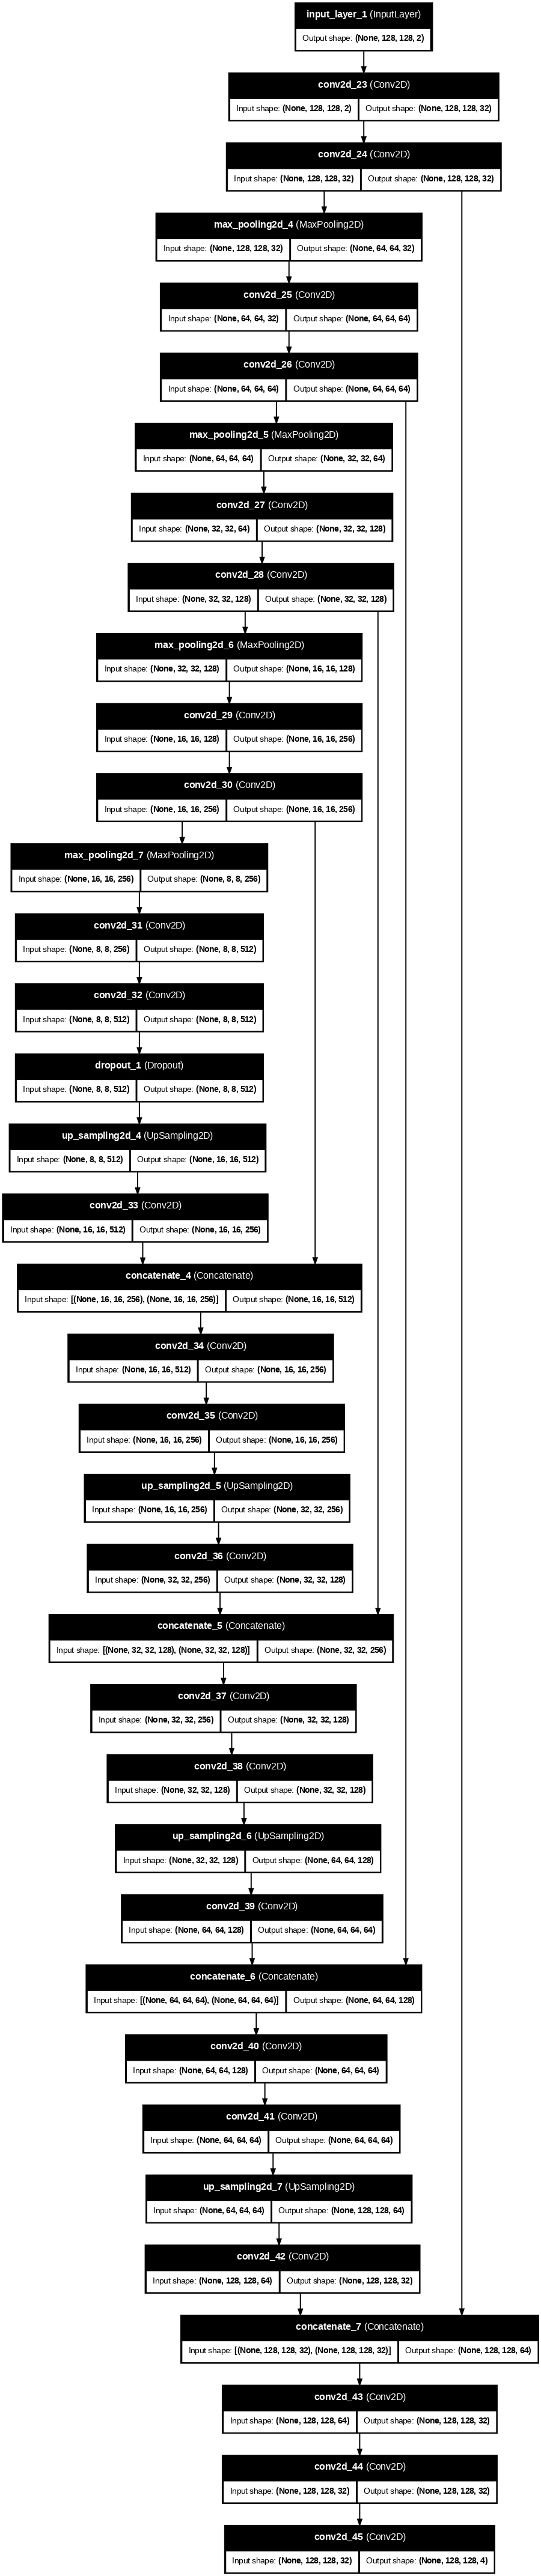

In [52]:
plot_model(model,
           show_shapes = True,
           show_dtype=False,
           show_layer_names = True,
           rankdir = 'TB',
           expand_nested = False,
           dpi = 70)

In [ ]:
!pip install segmentation-models

# Load data
Loading all data into memory is not a good idea since the data are too big to fit in.
So we will create dataGenerators - load data on the fly as explained [here](https://stanford.edu/~shervine/blog/keras-how-to-generate-data-on-the-fly)

In [53]:
# lists of directories with studies
train_and_val_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]

# file BraTS20_Training_355 has ill formatted name for for seg.nii file
bad_case = os.path.join(TRAIN_DATASET_PATH, 'BraTS20_Training_355')
if bad_case in train_and_val_directories:
    train_and_val_directories.remove(bad_case)


def pathListIntoIds(dirList):
    x = []
    for directory_path in dirList:
        x.append(os.path.basename(directory_path))
    return x

train_and_test_ids = pathListIntoIds(train_and_val_directories);


train_test_ids, val_ids = train_test_split(train_and_test_ids,test_size=0.2)
train_ids, test_ids = train_test_split(train_test_ids,test_size=0.15)

**Override Keras sequence DataGenerator class**

In [54]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.2, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),
    A.RandomBrightnessContrast(p=0.2),
    A.RandomGamma(p=0.2),
    A.GaussNoise(p=0.2),
])

class DataGenerator(keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, list_IDs, dim=(IMG_SIZE,IMG_SIZE), batch_size = 1, n_channels = 2, shuffle=True, augment=False):
        'Initialization'
        self.dim = dim
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.n_channels = n_channels
        self.shuffle = shuffle
        self.augment = augment
        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        # Generate indexes of the batch
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        # Find list of IDs
        Batch_ids = [self.list_IDs[k] for k in indexes]

        # Generate data
        X, y = self.__data_generation(Batch_ids)

        return X, y

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, Batch_ids):
        'Generates data containing batch_size samples' # X : (n_samples, *dim, n_channels)
        # Initialization
        X = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, self.n_channels))
        y = np.zeros((self.batch_size*VOLUME_SLICES, 240, 240))
        Y = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, 4))


        # Generate data
        for c, i in enumerate(Batch_ids):
            case_path = os.path.join(TRAIN_DATASET_PATH, i)

            data_path = os.path.join(case_path, f'{i}_flair.nii');
            flair = nib.load(data_path).get_fdata()

            data_path = os.path.join(case_path, f'{i}_t1ce.nii');
            ce = nib.load(data_path).get_fdata()

            data_path = os.path.join(case_path, f'{i}_seg.nii');
            seg = nib.load(data_path).get_fdata()

            for j in range(VOLUME_SLICES):
                 img_flair = cv2.resize(flair[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));
                 img_ce = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));
                 img_seg = seg[:,:,j+VOLUME_START_AT];
                 
                 if self.augment:
                     # Albumentations expects HWC. Stack modalities.
                     combined = np.stack([img_flair, img_ce], axis=-1)
                     # Resize seg to IMG_SIZE for augmentation
                     img_seg_resized = cv2.resize(img_seg, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
                     augmented = train_transform(image=combined, mask=img_seg_resized)
                     img_flair = augmented['image'][:,:,0]
                     img_ce = augmented['image'][:,:,1]
                     img_seg_final = augmented['mask']
                 else:
                     img_seg_final = img_seg

                 X[j +VOLUME_SLICES*c,:,:,0] = img_flair
                 X[j +VOLUME_SLICES*c,:,:,1] = img_ce
                 if self.augment:
                     # If augmented, it's already resized
                     y_temp = img_seg_final
                 else:
                     # Original logic had y as (batch, 240, 240) then tf.image.resize
                     y_temp = img_seg_final
                 
                 y[j +VOLUME_SLICES*c] = cv2.resize(y_temp, (240, 240), interpolation=cv2.INTER_NEAREST)

        # Generate masks
        y[y==4] = 3;
        mask = tf.one_hot(y, 4);
        Y = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE));
        return X/np.max(X), Y

training_generator = DataGenerator(train_ids, augment=True)
valid_generator = DataGenerator(val_ids, augment=False)
test_generator = DataGenerator(test_ids, augment=False)

class DataGenerator3D(keras.utils.Sequence):
    'Generates 3D data for Keras'
    def __init__(self, list_IDs, dim=(64,64,64), batch_size = 1, n_channels = 2, shuffle=True):
        'Initialization'
        self.dim = dim
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.n_channels = n_channels
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        Batch_ids = [self.list_IDs[k] for k in indexes]
        X, y = self.__data_generation(Batch_ids)
        return X, y

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, Batch_ids):
        X = np.zeros((self.batch_size, *self.dim, self.n_channels))
        Y = np.zeros((self.batch_size, *self.dim, 4))

        for c, i in enumerate(Batch_ids):
            case_path = os.path.join(TRAIN_DATASET_PATH, i)
            flair = nib.load(os.path.join(case_path, f'{i}_flair.nii')).get_fdata()
            ce = nib.load(os.path.join(case_path, f'{i}_t1ce.nii')).get_fdata()
            seg = nib.load(os.path.join(case_path, f'{i}_seg.nii')).get_fdata()

            # Simplified 3D crop/resize
            # For simplicity, we just take the central VOLUME_SLICES and resize each 2D slice
            # and then resize the depth if necessary. 
            # A better way would be 3D interpolation.
            
            # Let's use 64x64x64 as dim
            depth_start = VOLUME_START_AT
            depth_end = VOLUME_START_AT + 64 # Assuming at least 64 slices from START_AT
            
            for slice_idx in range(64):
                X[c, slice_idx, :, :, 0] = cv2.resize(flair[:, :, depth_start + slice_idx], (self.dim[1], self.dim[2]))
                X[c, slice_idx, :, :, 1] = cv2.resize(ce[:, :, depth_start + slice_idx], (self.dim[1], self.dim[2]))
                
                seg_slice = seg[:, :, depth_start + slice_idx]
                seg_slice[seg_slice == 4] = 3
                seg_slice_resized = cv2.resize(seg_slice, (self.dim[1], self.dim[2]), interpolation=cv2.INTER_NEAREST)
                Y[c, slice_idx, :, :, :] = tf.one_hot(seg_slice_resized, 4)

        return X/np.max(X) if np.max(X) > 0 else X, Y

**Number of data used**
for training / testing / validation

/tmp/ipykernel_25089/1596146384.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


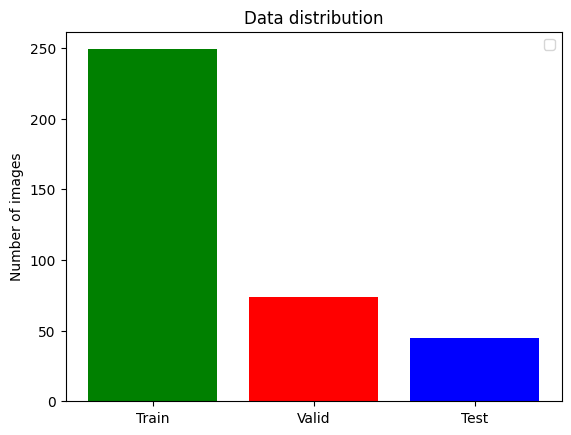

In [55]:
# show number of data for each dir
def showDataLayout():
    plt.bar(["Train","Valid","Test"],
    [len(train_ids), len(val_ids), len(test_ids)], align='center',color=[ 'green','red', 'blue'])
    plt.legend()

    plt.ylabel('Number of images')
    plt.title('Data distribution')

    plt.show()

showDataLayout()

**Add callback for training process**

In [56]:
csv_logger = CSVLogger('training.log', separator=',', append=False)

callbacks = [
    # Stop training when val_loss stops improving for 5 epochs and restore best weights
    keras.callbacks.EarlyStopping(
        monitor='val_loss', min_delta=1e-4,
        patience=5, verbose=1, mode='auto',
        restore_best_weights=True
    ),
    # Halve LR when val_loss plateaus for 3 epochs
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2,
        patience=3, min_lr=1e-6, verbose=1
    ),
    # Save the best model automatically
    keras.callbacks.ModelCheckpoint(
        filepath='3D_MRI_Brain_tumor_segmentation.h5',
        monitor='val_loss', verbose=1,
        save_best_only=True, save_weights_only=False
    ),
    csv_logger
]

# Train model
My best model was trained with 81% accuracy on mean IOU and 65.5% on Dice loss <br>
I will load this pretrained model instead of training again

In [57]:
K.clear_session()
# I train by 35 epochs but for time i will use 15 epochs
history =  model.fit(training_generator,
                    epochs=15,
                     steps_per_epoch=len(train_ids),
                     callbacks= callbacks,
                     validation_data = valid_generator
                     )
model.save("3D_MRI_Brain_tumor_segmentation.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 30s/step - accuracy: 0.9598 - dice_coef: 0.2520 - dice_coef_edema: 0.0830 - dice_coef_enhancing: 0.0348 - dice_coef_necrotic: 0.0330 - loss: 0.2284 - mean_io_u_1: 0.3756 - precision: 0.9584 - sensitivity: 0.9292 - specificity: 0.9947 
Epoch 1: val_loss improved from inf to 0.07581, saving model to 3D_MRI_Brain_tumor_segmentation.h5


249/249 ━━━━━━━━━━━━━━━━━━━━ 8238s 33s/step - accuracy: 0.9599 - dice_coef: 0.2520 - dice_coef_edema: 0.0830 - dice_coef_enhancing: 0.0348 - dice_coef_necrotic: 0.0330 - loss: 0.2279 - mean_io_u_1: 0.3756 - precision: 0.9585 - sensitivity: 0.9294 - specificity: 0.9947 - val_accuracy: 0.9835 - val_dice_coef: 0.2630 - val_dice_coef_edema: 0.0562 - val_dice_coef_enhancing: 0.0146 - val_dice_coef_necrotic: 0.0408 - val_loss: 0.0758 - val_mean_io_u_1: 0.3756 - val_precision: 0.9835 - val_sensitivity: 0.9835 - val_specificity: 0.9945 - learning_rate: 0.0010
Epoch 2/15
152/249 ━━━━━━━━━━━━━━━━━━━━ 49:48 31s/step - accuracy: 0.9856 - dice_coef: 0.2696 - dice_coef_edema: 0.1024 - dice_coef_enhancing: 0.0343 - dice_coef_necrotic: 0.0461 - loss: 0.0730 - mean_io_u_1: 0.3755 - precision: 0.9859 - sensitivity: 0.9854 - specificity: 0.9953

KeyboardInterrupt: 

**Visualize the training process**

In [ ]:
import tensorflow as tf
import numpy as np
import nibabel as nib
import cv2
import os

# Load the saved model if available; otherwise keep current in-memory model
model_path = "3D_MRI_Brain_tumor_segmentation.h5"
if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path, custom_objects={
        'dice_coef': dice_coef,
        'precision': precision,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'dice_coef_necrotic': dice_coef_necrotic,
        'dice_coef_edema': dice_coef_edema,
        'dice_coef_enhancing': dice_coef_enhancing
    })
else:
    print(f"Model file not found: {model_path}. Using current model in memory.")

def preprocess_image(image_file, slice_index=None):
    # Load the NIfTI file
    img = nib.load(image_file).get_fdata()

    # Select a specific slice if needed
    if slice_index is not None:
        img = img[:, :, slice_index]

    # Resize the image to (IMG_SIZE, IMG_SIZE)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalize the image
    img_resized = img_resized / np.max(img_resized)

    return img_resized

def predict(image_paths, slice_index):
    X = np.zeros((1, IMG_SIZE, IMG_SIZE, 2))

    # Process specific slices from the images
    X[0, :, :, 0] = preprocess_image(image_paths[0], slice_index)
    X[0, :, :, 1] = preprocess_image(image_paths[1], slice_index)

    # Make prediction
    pred = model.predict(X)

    return np.argmax(pred[0], axis=-1)

# Example usage (local path)
validation_case = 'BraTS20_Validation_010'
image_paths = [
    os.path.join(VALIDATION_DATASET_PATH, validation_case, f'{validation_case}_flair.nii'),
    os.path.join(VALIDATION_DATASET_PATH, validation_case, f'{validation_case}_t1ce.nii')
]

slice_index = 75  # Example slice index
prediction = predict(image_paths, slice_index)


In [ ]:
import numpy as np

def get_classification(pred):
    # Get the class with the highest probability for each pixel
    class_predictions = np.argmax(pred, axis=-1)
    return class_predictions


In [ ]:
get_classification(prediction)

In [ ]:
import matplotlib.pyplot as plt

def visualize_prediction(prediction):
    plt.imshow(prediction, cmap='nipy_spectral')  # 'nipy_spectral' gives distinct colors for different classes
    plt.title('Predicted Segmentation')
    plt.colorbar()
    plt.show()


In [ ]:
visualize_prediction(prediction)

In [ ]:
import os

############ load trained model ################
candidate_model_paths = [
    '../input/modelperclasseval/model_per_class.h5',
    '3D_MRI_Brain_tumor_segmentation.h5'
 ]

for model_path in candidate_model_paths:
    if os.path.exists(model_path):
        model = keras.models.load_model(model_path,
            custom_objects={ 'accuracy' : tf.keras.metrics.MeanIoU(num_classes=4),
                            "dice_coef": dice_coef,
                            "precision": precision,
                            "sensitivity":sensitivity,
                            "specificity":specificity,
                            "dice_coef_necrotic": dice_coef_necrotic,
                            "dice_coef_edema": dice_coef_edema,
                            "dice_coef_enhancing": dice_coef_enhancing
                           }, compile=False)
        print(f"Loaded model from: {model_path}")
        break
else:
    print("No pretrained model file found. Using current model in memory.")

candidate_log_paths = [
    '../input/modelperclasseval/training_per_class.log',
    'training.log'
 ]

hist = None
for log_path in candidate_log_paths:
    if os.path.exists(log_path):
        try:
            hist = pd.read_csv(log_path, sep=',', engine='python')
            if len(hist) > 0:
                print(f"Loaded training log from: {log_path}")
                break
            hist = None
        except Exception:
            hist = None

if hist is None and 'history' in globals() and hasattr(history, 'history'):
    hist = pd.DataFrame(history.history)
    print("Using in-memory history from current session.")

if hist is not None and len(hist) > 0:
    acc=hist['accuracy']
    val_acc=hist['val_accuracy']

    epoch=range(len(acc))

    loss=hist['loss']
    val_loss=hist['val_loss']

    train_dice=hist['dice_coef']
    val_dice=hist['val_dice_coef']

    f,ax=plt.subplots(1,4,figsize=(16,8))

    ax[0].plot(epoch,acc,'b',label='Training Accuracy')
    ax[0].plot(epoch,val_acc,'r',label='Validation Accuracy')
    ax[0].legend()

    ax[1].plot(epoch,loss,'b',label='Training Loss')
    ax[1].plot(epoch,val_loss,'r',label='Validation Loss')
    ax[1].legend()

    ax[2].plot(epoch,train_dice,'b',label='Training dice coef')
    ax[2].plot(epoch,val_dice,'r',label='Validation dice coef')
    ax[2].legend()

    ax[3].plot(epoch,hist['mean_io_u'],'b',label='Training mean IOU')
    ax[3].plot(epoch,hist['val_mean_io_u'],'r',label='Validation mean IOU')
    ax[3].legend()

    plt.show()
else:
    print("No training history available to plot.")

# Prediction examples

In [ ]:
# mri type must one of 1) flair 2) t1 3) t1ce 4) t2 ------- or even 5) seg
# returns volume of specified study at `path`
def imageLoader(path):
    image = nib.load(path).get_fdata()
    X = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, self.n_channels))
    for j in range(VOLUME_SLICES):
        X[j +VOLUME_SLICES*c,:,:,0] = cv2.resize(image[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));
        X[j +VOLUME_SLICES*c,:,:,1] = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE));

        y[j +VOLUME_SLICES*c] = seg[:,:,j+VOLUME_START_AT];
    return np.array(image)


# load nifti file at `path`
# and load each slice with mask from volume
# choose the mri type & resize to `IMG_SIZE`
def loadDataFromDir(path, list_of_files, mriType, n_images):
    scans = []
    masks = []
    for i in list_of_files[:n_images]:
        fullPath = glob.glob( i + '/*'+ mriType +'*')[0]
        currentScanVolume = imageLoader(fullPath)
        currentMaskVolume = imageLoader( glob.glob( i + '/*seg*')[0] )
        # for each slice in 3D volume, find also it's mask
        for j in range(0, currentScanVolume.shape[2]):
            scan_img = cv2.resize(currentScanVolume[:,:,j], dsize=(IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA).astype('uint8')
            mask_img = cv2.resize(currentMaskVolume[:,:,j], dsize=(IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_AREA).astype('uint8')
            scans.append(scan_img[..., np.newaxis])
            masks.append(mask_img[..., np.newaxis])
    return np.array(scans, dtype='float32'), np.array(masks, dtype='float32')

#brains_list_test, masks_list_test = loadDataFromDir(VALIDATION_DATASET_PATH, test_directories, "flair", 5)


In [ ]:
def predictByPath(case_path,case):
    files = next(os.walk(case_path))[2]
    X = np.empty((VOLUME_SLICES, IMG_SIZE, IMG_SIZE, 2))
  #  y = np.empty((VOLUME_SLICES, IMG_SIZE, IMG_SIZE))

    vol_path = os.path.join(case_path, f'BraTS20_Training_{case}_flair.nii');
    flair=nib.load(vol_path).get_fdata()

    vol_path = os.path.join(case_path, f'BraTS20_Training_{case}_t1ce.nii');
    ce=nib.load(vol_path).get_fdata()

 #   vol_path = os.path.join(case_path, f'BraTS20_Training_{case}_seg.nii');
 #   seg=nib.load(vol_path).get_fdata()


    for j in range(VOLUME_SLICES):
        X[j,:,:,0] = cv2.resize(flair[:,:,j+VOLUME_START_AT], (IMG_SIZE,IMG_SIZE))
        X[j,:,:,1] = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE,IMG_SIZE))
 #       y[j,:,:] = cv2.resize(seg[:,:,j+VOLUME_START_AT], (IMG_SIZE,IMG_SIZE))

  #  model.evaluate(x=X,y=y[:,:,:,0], callbacks= callbacks)
    return model.predict(X/np.max(X), verbose=1)


def showPredictsById(case, start_slice = 60):
    path = os.path.join(TRAIN_DATASET_PATH, f"BraTS20_Training_{case}")
    gt = nib.load(os.path.join(path, f'BraTS20_Training_{case}_seg.nii')).get_fdata()
    origImage = nib.load(os.path.join(path, f'BraTS20_Training_{case}_flair.nii')).get_fdata()
    p = predictByPath(path,case)

    core = p[:,:,:,1]
    edema= p[:,:,:,2]
    enhancing = p[:,:,:,3]

    plt.figure(figsize=(18, 50))
    f, axarr = plt.subplots(1,6, figsize = (18, 50))

    for i in range(6): # for each image, add brain background
        axarr[i].imshow(cv2.resize(origImage[:,:,start_slice+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE)), cmap="gray", interpolation='none')

    axarr[0].imshow(cv2.resize(origImage[:,:,start_slice+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE)), cmap="gray")
    axarr[0].title.set_text('Original image flair')
    curr_gt=cv2.resize(gt[:,:,start_slice+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE), interpolation = cv2.INTER_NEAREST)
    axarr[1].imshow(curr_gt, cmap="Reds", interpolation='none', alpha=0.3) # ,alpha=0.3,cmap='Reds'
    axarr[1].title.set_text('Ground truth')
    axarr[2].imshow(p[start_slice,:,:,1:4], cmap="Reds", interpolation='none', alpha=0.3)
    axarr[2].title.set_text('all classes')
    axarr[3].imshow(edema[start_slice,:,:], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[3].title.set_text(f'{SEGMENT_CLASSES[1]} predicted')
    axarr[4].imshow(core[start_slice,:,], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[4].title.set_text(f'{SEGMENT_CLASSES[2]} predicted')
    axarr[5].imshow(enhancing[start_slice,:,], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[5].title.set_text(f'{SEGMENT_CLASSES[3]} predicted')
    plt.show()


showPredictsById(case=test_ids[0][-3:])
showPredictsById(case=test_ids[1][-3:])
showPredictsById(case=test_ids[2][-3:])
showPredictsById(case=test_ids[3][-3:])
showPredictsById(case=test_ids[4][-3:])
showPredictsById(case=test_ids[5][-3:])
showPredictsById(case=test_ids[6][-3:])


# mask = np.zeros((10,10))
# mask[3:-3, 3:-3] = 1 # white square in black background
# im = mask + np.random.randn(10,10) * 0.01 # random image
# masked = np.ma.masked_where(mask == 0, mask)

# plt.figure()
# plt.subplot(1,2,1)
# plt.imshow(im, 'gray', interpolation='none')
# plt.subplot(1,2,2)
# plt.imshow(im, 'gray', interpolation='none')
# plt.imshow(masked, 'jet', interpolation='none', alpha=0.7)
# plt.show()

In [ ]:
# Model Comparison Framework
# Here we define and compile all 6 models for comparison

results_summary = {}

def get_compiled_model(model_name, input_shape=(128, 128, 2)):
    if model_name == "Baseline_UNet":
        inputs = Input(input_shape)
        m = build_unet(inputs)
        m.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(0.001), metrics=[dice_coef])
    elif model_name == "Baseline_UNet_Dice":
        inputs = Input(input_shape)
        m = build_unet(inputs)
        m.compile(loss=dice_loss, optimizer=keras.optimizers.Adam(0.001), metrics=[dice_coef])
    elif model_name == "ResNet_UNet":
        m = build_resnet_unet(input_shape=input_shape)
        m.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(0.001), metrics=[dice_coef])
    elif model_name == "Attention_UNet":
        m = build_attention_unet(input_shape=input_shape)
        m.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(0.001), metrics=[dice_coef])
    elif model_name == "UNet_3D":
        # Note: 3D U-Net requires different input shape (64, 64, 64, 2)
        m = build_unet_3d(input_shape=(64, 64, 64, 2))
        m.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(0.001), metrics=[dice_coef])
    else:
        return None
    return m

# Comparison Initiation
model_names = ["Baseline_UNet", "Baseline_UNet_Dice", "ResNet_UNet", "Attention_UNet"]

print("--- Model Comparison Initiation ---")
for name in model_names:
    print(f"
Preparing {name}...")
    model_to_test = get_compiled_model(name)
    if model_to_test:
        print(f"{name} compiled successfully.")

# 3D U-Net handling
print("
Preparing UNet_3D...")
model_3d = get_compiled_model("UNet_3D")
if model_3d:
    print("UNet_3D compiled successfully.")

# SVM Baseline
print("
SVM Baseline available via train_svm_baseline() and predict_svm()")


# Evaluation

In [ ]:
case = case=test_ids[3][-3:]
path = os.path.join(TRAIN_DATASET_PATH, f"BraTS20_Training_{case}")
gt = nib.load(os.path.join(path, f'BraTS20_Training_{case}_seg.nii')).get_fdata()
p = predictByPath(path,case)


core = p[:,:,:,1]
edema= p[:,:,:,2]
enhancing = p[:,:,:,3]


i=40 # slice at
eval_class = 2 #     0 : 'NOT tumor',  1 : 'ENHANCING',    2 : 'CORE',    3 : 'WHOLE'


gt[gt != eval_class] = 1 # use only one class for per class evaluation

resized_gt = cv2.resize(gt[:,:,i+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE))

plt.figure()
f, axarr = plt.subplots(1,2)
axarr[0].imshow(resized_gt, cmap="gray")
axarr[0].title.set_text('ground truth')
axarr[1].imshow(p[i,:,:,eval_class], cmap="gray")
axarr[1].title.set_text(f'predicted class: {SEGMENT_CLASSES[eval_class]}')
plt.show()

In [ ]:
model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.001), metrics = ['accuracy',tf.keras.metrics.MeanIoU(num_classes=4), dice_coef, precision, sensitivity, specificity, dice_coef_necrotic, dice_coef_edema, dice_coef_enhancing] )
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model.evaluate(test_generator, batch_size=100, callbacks= callbacks)
print("test loss, test acc:", results)

def model_builder(hp):
    input_layer = Input((IMG_SIZE, IMG_SIZE, 2))
    
    # Tune the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    # Tune dropout rate
    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
    
    model = build_unet(input_layer, 'he_normal', hp_dropout)
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                loss="categorical_crossentropy",
                metrics=['accuracy', dice_coef])
    
    return model

tuner = kt.Hyperband(model_builder,
                     objective='val_accuracy',
                     max_epochs=10,
                     factor=3,
                     directory='my_dir',
                     project_name='intro_to_kt')

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# tuner.search(training_generator, epochs=50, validation_data=valid_generator, callbacks=[stop_early])

# Task
Please provide your GitHub Personal Access Token (PAT) with `repo` scope to proceed. The token will be stored securely for this session only. You can generate one at [https://github.com/settings/tokens](https://github.com/settings/tokens) (classic tokens) or [https://github.com/settings/tokens/new](https://github.com/settings/tokens/new) (fine-grained tokens, recommended).

## Prepare GitHub Token

### Subtask:
Obtain and securely store your GitHub Personal Access Token (PAT) with `repo` scope.


### Subtask
Obtain and securely store your GitHub Personal Access Token (PAT) with `repo` scope.

#### Instructions
1. Go to your GitHub settings page to generate a new Personal Access Token (PAT). You can use either [https://github.com/settings/tokens](https://github.com/settings/tokens) for classic tokens or [https://github.com/settings/tokens/new](https://github.com/settings/tokens/new) for fine-grained tokens (recommended).
2. When creating the token, ensure it has the `repo` scope (for classic tokens) or appropriate repository permissions (for fine-grained tokens) to allow the notebook to create and push to repositories.
3. Copy the generated token.
4. In a new code cell, assign your copied GitHub PAT to a variable named `GITHUB_TOKEN`. For example: `GITHUB_TOKEN = 'your_pat_here'`. This token will be stored securely for this session only.

**Reasoning**:
A code cell is needed to allow the user to input their generated GitHub PAT, as instructed in the previous markdown block. This cell provides a placeholder for the token.



In [ ]:
GITHUB_TOKEN = 'YOUR_PAT_HERE' # Replace 'YOUR_PAT_HERE' with your actual GitHub Personal Access Token